In [ ]:
import sys
import os
import subprocess
import json
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display, Image

sys.path.append('/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/SRC/')

from decisao_multicriterio.MCDA_DecisaoSubjetiva import *
from decisao_multicriterio.MCDA_DecisaoDados import *

In [ ]:
# Caminho para o script Julia
script = "pareto_despacho_economico"    
script_julia = "/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/SRC/modelos_matematicos/"+script+".jl"

if not os.path.exists(script_julia):
    print(f"Arquivo Julia '{script_julia}' não encontrado.")
    sys.exit(1)
else:
    # Comando para executar
    comando = ["julia", script_julia]
    print(f"Executando '{script_julia}' via subprocesso...")

    # Executa e captura a saída
    try:
        resultado = subprocess.run(comando, capture_output=True, text=True, check=True)
        print("Execução concluída com sucesso:")
        print(resultado.stdout)
    except subprocess.CalledProcessError as e:
        print("Erro durante a execução do script Julia:")
        print(e.stderr)


Image(filename='/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/relatorios/pareto.png')

In [ ]:
# Caminho do arquivo
path = "/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/DATA/output/input_alternativas.json"

with open(path, "r") as f:
    DATA = json.load(f)

# Analise FluxPot e Preço

In [ ]:
def analisa_cenario(data):
    # Convertendo para DataFrame
    resultados = data['resultados']

    # Preparando dados para geração por hora
    horas = [entry['hora'] for entry in resultados]
    geradores = ['G1', 'G2', 'G3', 'G4', 'Defict']
    geracao_por_hora = {gerador: [entry['geracao'][gerador] for entry in resultados] for gerador in geradores}
    dados_emissao = {gerador: [entry['emissao'][gerador] for entry in resultados] for gerador in geradores}
    emissoes_por_hora = [sum(valores) for valores in zip(dados_emissao['G1'],
                                                         dados_emissao['G2'],
                                                         dados_emissao['G3'],
                                                         dados_emissao['G4'],
                                                         dados_emissao['Defict'])]
    
    # Criando figura com eixo secundário
    fig, ax1 = plt.subplots(figsize=(15, 8))

    # Plotando gráfico de barras empilhadas para geração
    bottom = [0] * len(horas)
    cores = ['red', 'orange', 'blue', 'green', 'purple']

    for i, gerador in enumerate(geradores):
        ax1.bar(horas, geracao_por_hora[gerador], bottom=bottom, 
                label=gerador, color=cores[i], alpha=0.8, width=0.6)
        bottom = [bottom[j] + geracao_por_hora[gerador][j] for j in range(len(horas))]

   
    ax2 = ax1.twinx()
    ax2.plot(horas, emissoes_por_hora, color='grey', linewidth=3, 
            marker='o', markersize=6, label='Emissão', linestyle='dashed')

    # Configurações do gráfico
    ax1.set_ylim(0, 80)    # Geração de 0 a 100 MW
    ax2.set_ylim(0, 160)    # Emissão de 0 a 200 tCO
    ax1.set_xlabel('Hora do Dia', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Geração (MW)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Emissão (tCO₂)', fontsize=12, fontweight='bold', color='grey')
    ax2.tick_params(axis='y', labelcolor='#2C3E50')

    ax1.set_title(f'Geração por Fonte e Emissões - Cenário  \n'
                f'Peso Custo: {data["peso_custo"]}, Peso Emissão: {data["peso_emissao"]}', 
                fontsize=14, fontweight='bold', pad=20)

    ax1.set_xticks(horas)
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.legend(loc='upper left', bbox_to_anchor=(0, 1))
    ax2.legend(loc='upper right', bbox_to_anchor=(1, 1))

    plt.tight_layout()
    plt.show()

    # Exibindo totais do cenário
    print(f"=== RESUMO DO CENÁRIO {data['cenario_id']} ===")
    print(f"Custo Total: {data['custo_total']:.2f} USD")
    print(f"Emissão Total: {data['emissao_total']:.2f} tCO₂")
    print(f"Peso Custo: {data['peso_custo']}")
    print(f"Peso Emissão: {data['peso_emissao']}")

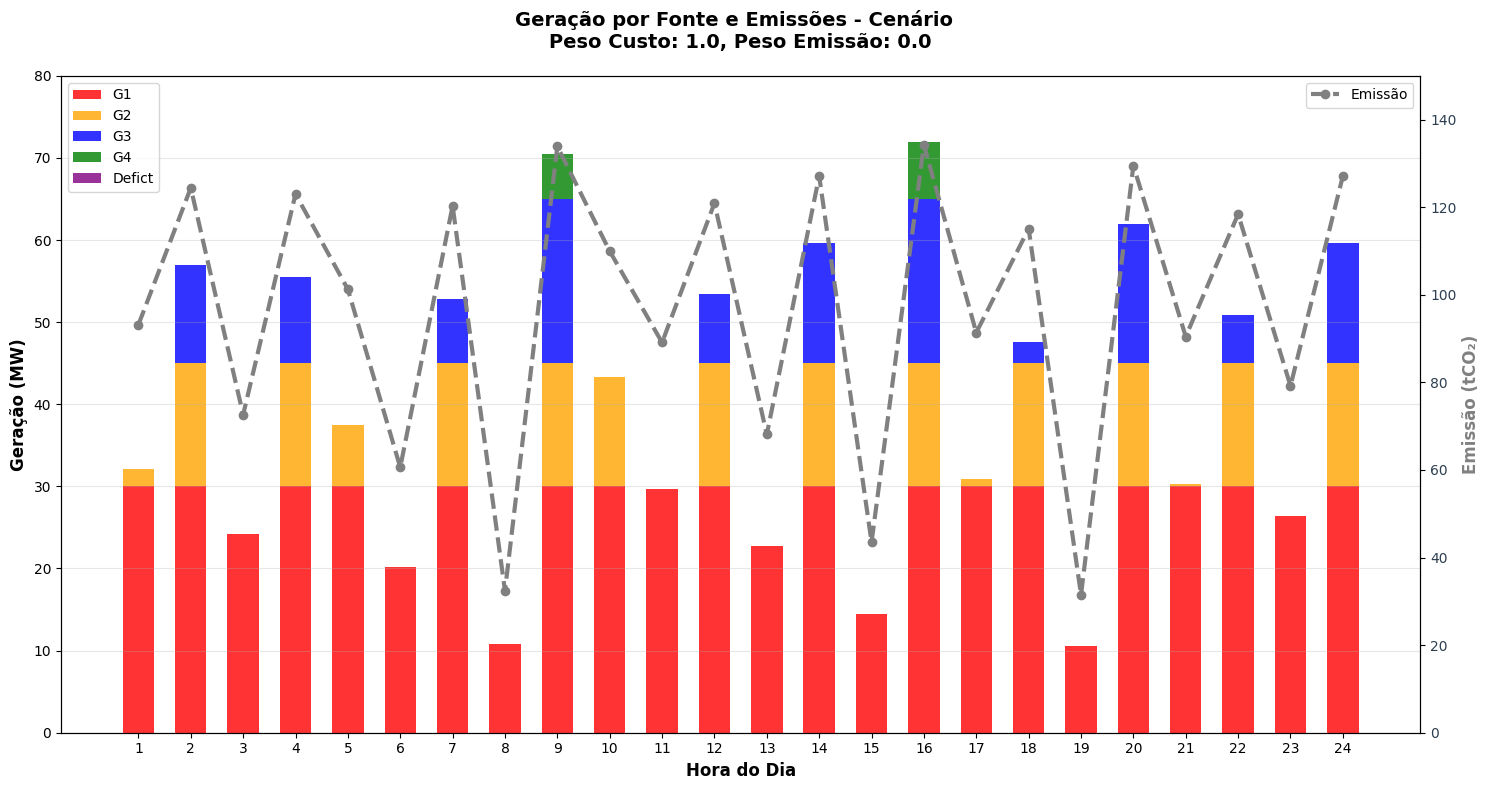

=== RESUMO DO CENÁRIO 0 ===
Custo Total: 11622.00 USD
Emissão Total: 2337.05 tCO₂
Peso Custo: 1.0
Peso Emissão: 0.0


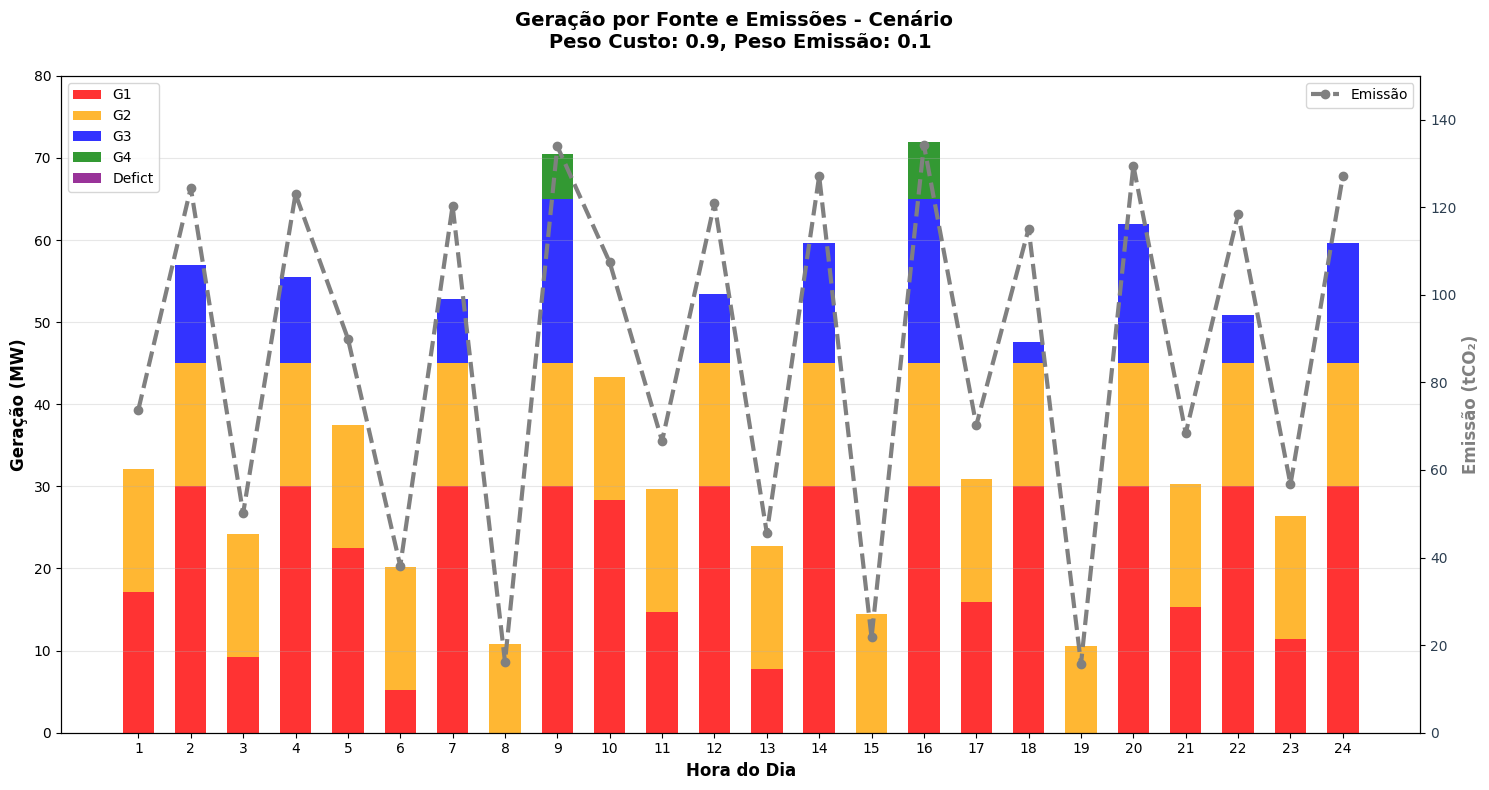

=== RESUMO DO CENÁRIO 1 ===
Custo Total: 11945.40 USD
Emissão Total: 2094.50 tCO₂
Peso Custo: 0.9
Peso Emissão: 0.1


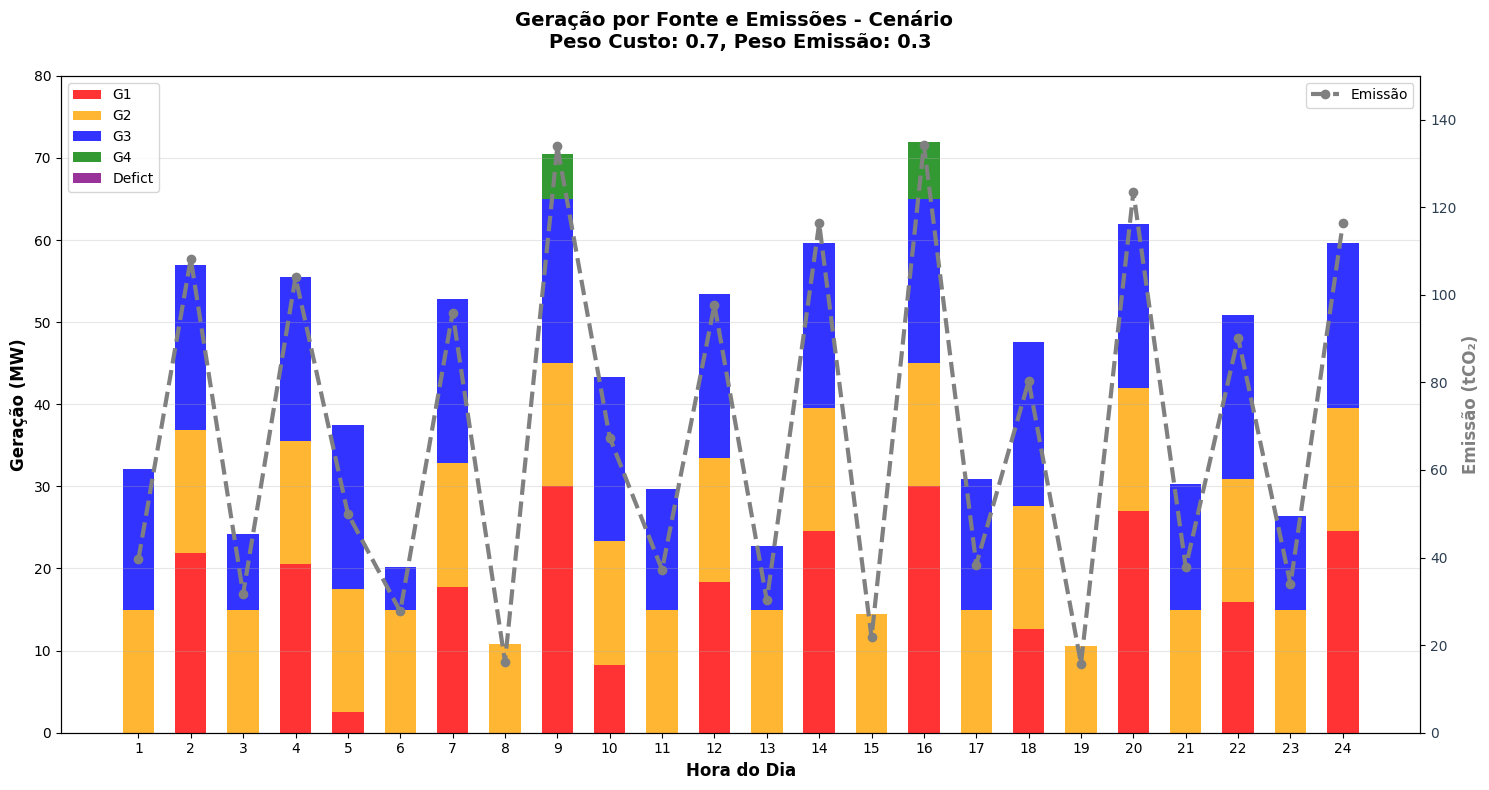

=== RESUMO DO CENÁRIO 3 ===
Custo Total: 16855.80 USD
Emissão Total: 1648.10 tCO₂
Peso Custo: 0.7
Peso Emissão: 0.3


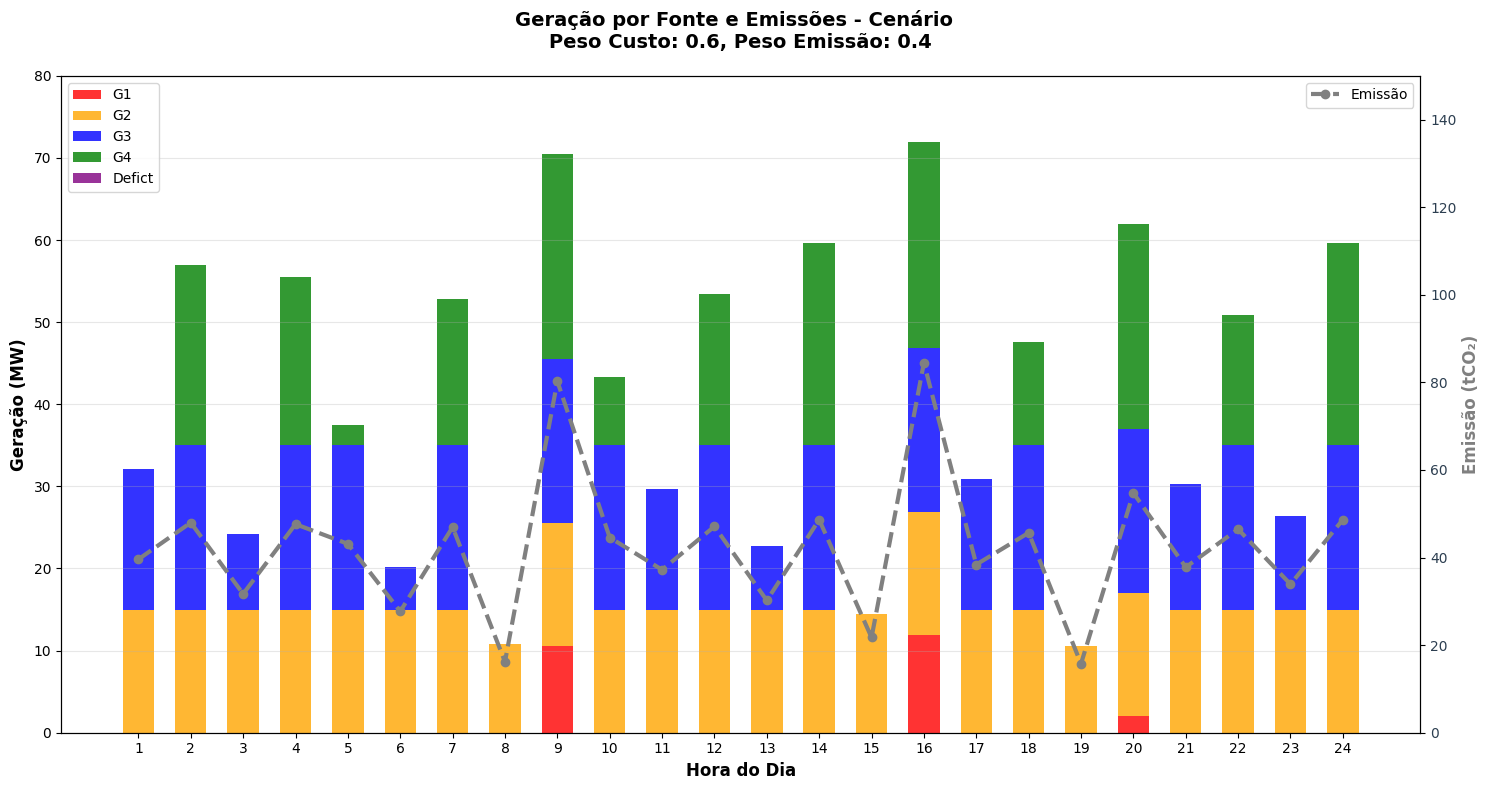

=== RESUMO DO CENÁRIO 4 ===
Custo Total: 26503.20 USD
Emissão Total: 1016.42 tCO₂
Peso Custo: 0.6
Peso Emissão: 0.4


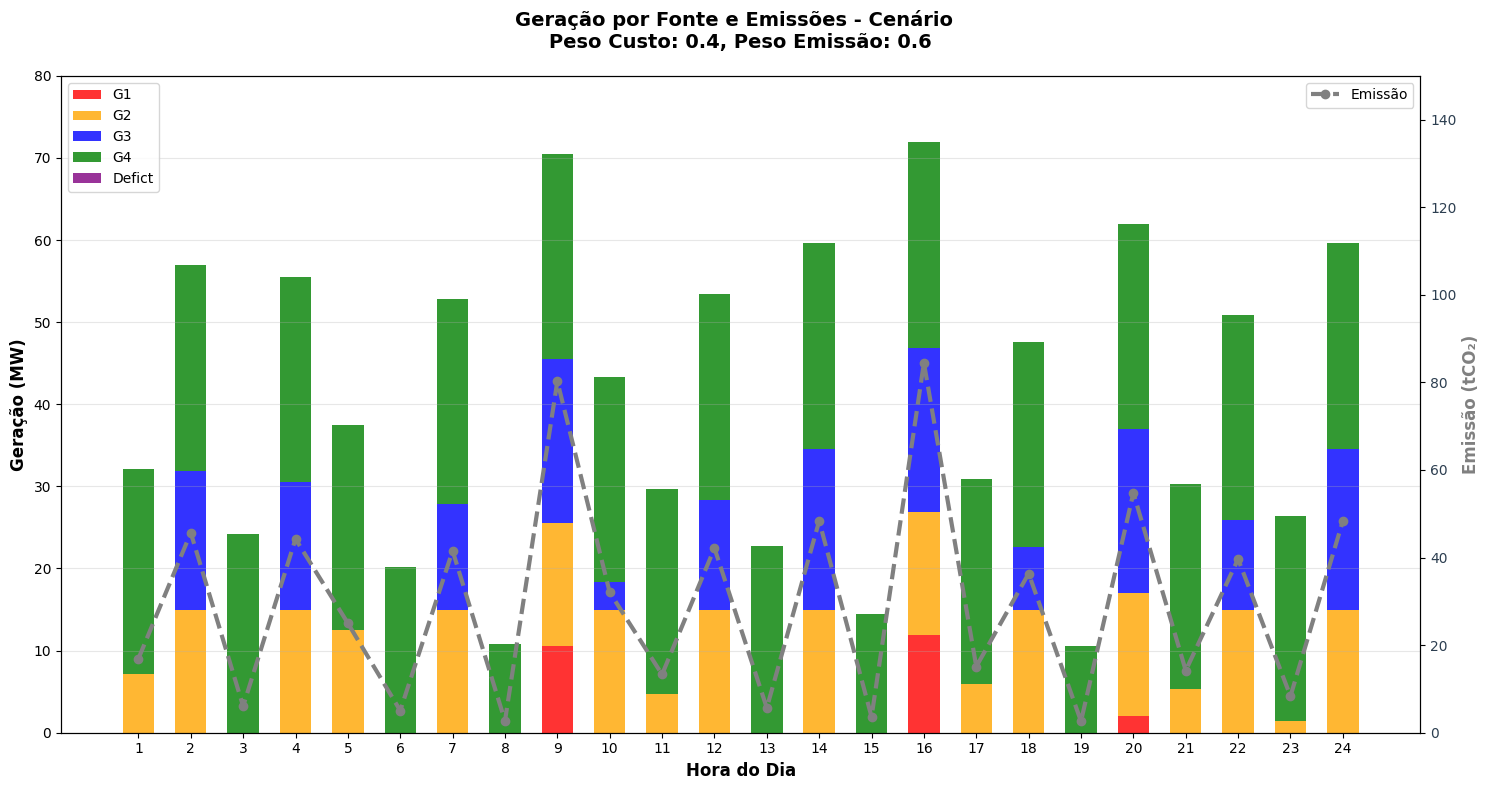

=== RESUMO DO CENÁRIO 6 ===
Custo Total: 35397.20 USD
Emissão Total: 716.37 tCO₂
Peso Custo: 0.4
Peso Emissão: 0.6


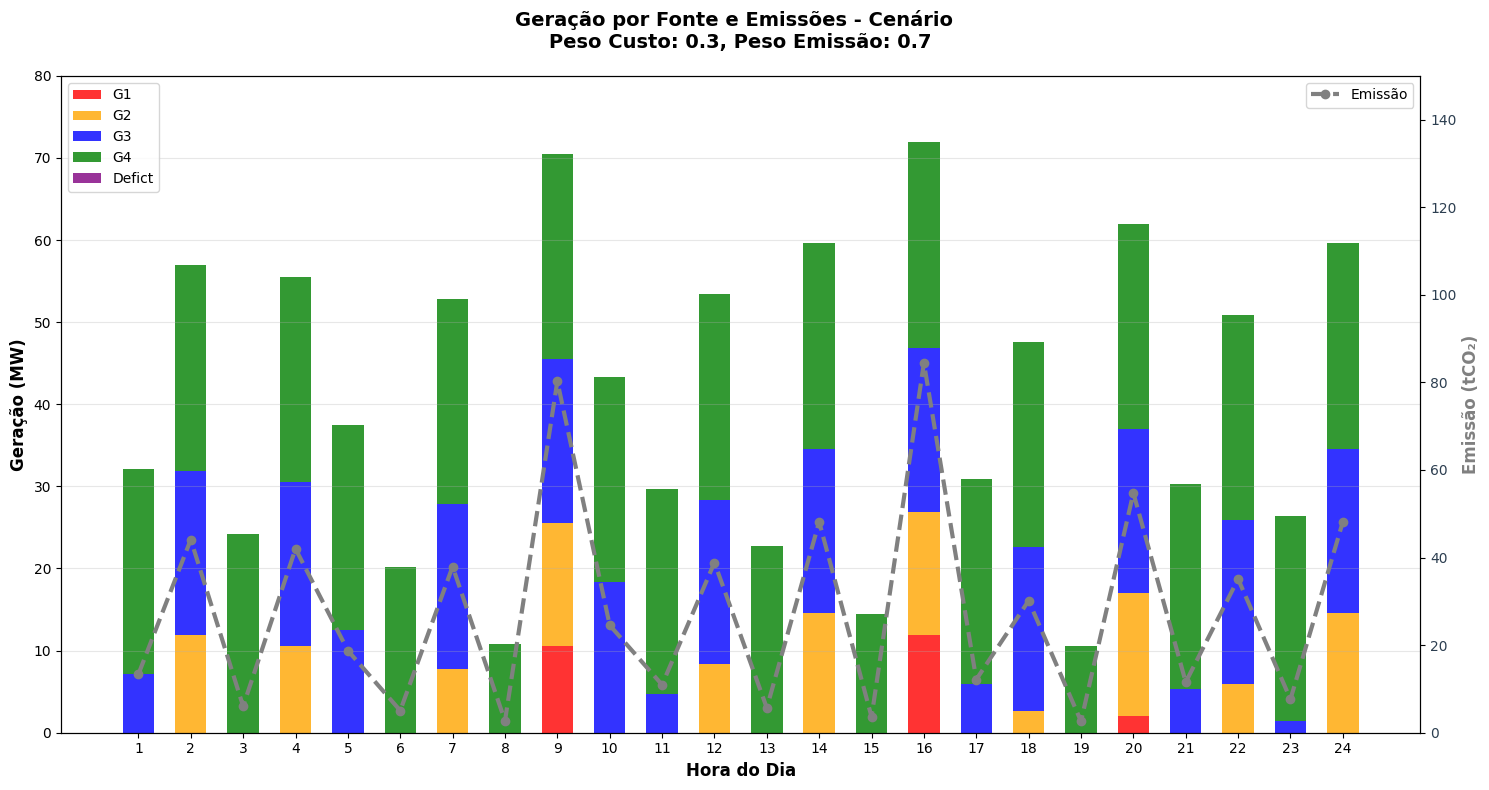

=== RESUMO DO CENÁRIO 7 ===
Custo Total: 37309.20 USD
Emissão Total: 668.58 tCO₂
Peso Custo: 0.3
Peso Emissão: 0.7


In [130]:
alternativas_cen = [0,1,3,4,6,7]
for cen in alternativas_cen:#range(0,11):
    # Lendo o arquivo JSON
    with open(f'/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/DATA/output/MCDA/fluxpot/output_fluxpot_cenario_{cen}.json', 'r') as file:
        data = json.load(file)
    
    analisa_cenario(data)

# Modelos Subjetivos

In [131]:
# Matriz de critérios para WASPAS (exemplo simplificado)
matriz_preferencias_decisor = pd.DataFrame({
    'Custo Operacao': [1, 2],
    'Emissao ton CO2': [1/2, 1]
}, index=['Custo Operacao','Emissao ton CO2'])

In [132]:
ahp = AHP(arquivo_alternativas=DATA, matriz_preferencias_decisor=matriz_preferencias_decisor).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios AHP:
Custo Operacao     0.667
Emissao ton CO2    0.333
dtype: float64

Ranking das Alternativas: - AHP 
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.205
1               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.203
2               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.160
3               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.148
4               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.145
5               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.139


In [133]:
waspas = WASPAS(arquivo_alternativas=DATA, matriz_preferencias_decisor=matriz_preferencias_decisor).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios WASPAS:
Custo Operacao     0.667
Emissao ton CO2    0.333
dtype: float64

Ranking das Alternativas: - WASPAS 
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.202
1               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.201
2               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.167
3               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.144
4               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.143
5               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.142


# Modelos Analíticos

In [134]:
ahp_gauss = AHP_Gaussiano(arquivo_alternativas=DATA).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios (AHP-Gaussiano):
Custo Operacao     0.49
Emissao ton CO2    0.51
dtype: float64

Ranking das Alternativas: - (AHP-Gaussiano)
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.182
1               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.175
2               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.173
3               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.171
4               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.151
5               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.148


In [135]:
lopcow = LOPCOW(arquivo_alternativas=DATA).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios LOPCOW:
Custo Operacao     0.48
Emissao ton CO2    0.52
dtype: float64

Ranking das Alternativas: - LOPCOW
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.186
1               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.181
2               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.167
3               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.164
4               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.157
5               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.146


In [136]:
mpsi = MPSI(arquivo_alternativas=DATA).rank_alternativas()

--------------------------------------------------------------------------------
Pesos dos critérios MPSI:
Custo Operacao     0.499
Emissao ton CO2    0.501
dtype: float64

Ranking das Alternativas: - MPSI
   id_alternativa         descricao  Custo Operacao  Emissao ton CO2  Score
0               6  w_c=0.3, w_e=0.7         37309.2           668.58  0.179
1               2  w_c=0.9, w_e=0.1         11945.4          2094.50  0.176
2               1  w_c=1.0, w_e=0.0         11622.0          2337.05  0.175
3               5  w_c=0.4, w_e=0.6         35397.2           716.37  0.172
4               4  w_c=0.6, w_e=0.4         26503.2          1016.42  0.149
5               3  w_c=0.7, w_e=0.3         16855.8          1648.10  0.149


In [137]:
 # Gera os rankings
df_ahp = ahp.rename(columns={"Score": "AHP"})
df_waspas = waspas.rename(columns={"Score": "WASPAS"})
#df_wisp = wisp.rename(columns={"Score": "WISP"})
df_ahp_gauss = ahp_gauss.rename(columns={"Score": "AHP_Gaussiano"})
df_lopcow = lopcow.rename(columns={"Score": "LOPCOW"})
df_mpsi = mpsi.rename(columns={"Score": "MPSI"})

# Seleciona colunas-chave
base_cols = ["id_alternativa", "descricao"]

df_merged =  df_ahp[base_cols + ["AHP"]] \
    .merge(df_waspas[base_cols + ["WASPAS"]], on=base_cols, how="outer") \
    .merge(df_ahp_gauss[base_cols + ["AHP_Gaussiano"]], on=base_cols, how="outer") \
    .merge(df_lopcow[base_cols + ["LOPCOW"]], on=base_cols, how="outer") \
    .merge(df_mpsi[base_cols + ["MPSI"]], on=base_cols, how="outer")       
    #.merge(df_wisp[base_cols + ["WISP"]], on=base_cols, how="outer")

# Ordena por uma média dos scores
df_merged = df_merged.fillna(0)
df_merged["Score_Medio"] = df_merged[["AHP","WASPAS","AHP_Gaussiano","LOPCOW", "MPSI"]].mean(axis=1)
df_merged = df_merged.sort_values(by="Score_Medio", ascending=False).reset_index(drop=True)

print('-'*90)
# Exporta para Excel
df_merged.to_excel("/home/lucasedbraga/projetos/ufjf/mestrado_luedsbr/relatorios/ranking_comparativo_metodos.xlsx", index=False)
print(df_merged)

------------------------------------------------------------------------------------------
   id_alternativa         descricao    AHP  WASPAS  AHP_Gaussiano  LOPCOW  \
0               2  w_c=0.9, w_e=0.1  0.203   0.202          0.173   0.167   
1               1  w_c=1.0, w_e=0.0  0.205   0.201          0.171   0.146   
2               6  w_c=0.3, w_e=0.7  0.148   0.143          0.182   0.157   
3               3  w_c=0.7, w_e=0.3  0.160   0.167          0.148   0.181   
4               5  w_c=0.4, w_e=0.6  0.145   0.142          0.175   0.164   
5               4  w_c=0.6, w_e=0.4  0.139   0.144          0.151   0.186   

    MPSI  Score_Medio  
0  0.176       0.1842  
1  0.175       0.1796  
2  0.179       0.1618  
3  0.149       0.1610  
4  0.172       0.1596  
5  0.149       0.1538  
